## Numpy高级功能
### 广播机制
广播机制描述了 NumPy 在进行算术运算时如何处理形状不同的数组。
在满足特定约束条件的情况下，较小的数组会被“广播”到较大的数组中，以确保它们的形状兼容。广播机制提供了一种向量化数组运算的方法，使得循环操作在 C 语言中执行，而不是在 Python 中执行。它避免了不必要的数据复制，通常能够实现高效的算法。然而，在某些情况下，广播机制并非最佳选择，因为它会导致内存使用效率低下，从而降低计算速度。

NumPy 操作通常是对成对数组逐元素进行的。最简单的情况下，两个数组必须具有完全相同的形状，如下例所示：

In [2]:
import numpy as np
a = np.array([1.0, 2.0, 3.0])
b = np.array([2.0, 2.0, 2.0])
a * b

array([2., 4., 6.])

当数组的形状满足某些约束条件时，NumPy 的广播规则会放宽这一限制。最简单的广播示例发生在数组和标量值组合运算中：


In [3]:
import numpy as np
a = np.array([1.0, 2.0, 3.0])
b = 2.0
a * b

array([2., 4., 6.])

结果与之前b是一个数组示例相同，我们可以将标量想象成在算术运算过程中b被拉伸成一个与 a形状相同的数组。如图 1所示，a中的新元素 只是原始标量的副本。这种拉伸的类比只是概念上的。NumPy 非常智能，它能够直接使用原始标量值而无需实际复制，从而使广播操作尽可能地节省内存和计算资源。
第二个示例中的代码比第一个示例中的代码效率更高，因为广播在乘法期间移动的内存更少.

In [4]:
import numpy as np
a = np.array([[ 0.0,  0.0,  0.0],
              [10.0, 10.0, 10.0],
              [20.0, 20.0, 20.0],
              [30.0, 30.0, 30.0]])
b = np.array([1.0, 2.0, 3.0])
a + b
b = np.array([1.0, 2.0, 3.0, 4.0])
a + b

ValueError: operands could not be broadcast together with shapes (4,3) (4,) 

广播机制提供了一种便捷的方式来计算两个数组的外积（或其他任何外运算）。以下示例展示了两个一维数组的外加运算：
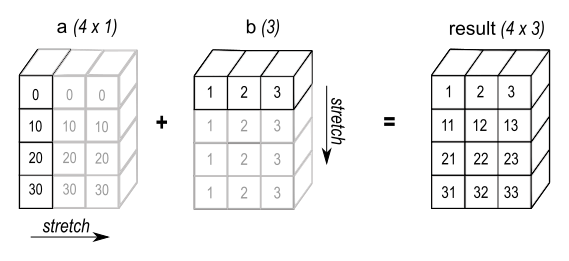

In [5]:
import numpy as np
a = np.array([0.0, 10.0, 20.0, 30.0])
b = np.array([1.0, 2.0, 3.0])
a[:, np.newaxis] + b

array([[ 1.,  2.,  3.],
       [11., 12., 13.],
       [21., 22., 23.],
       [31., 32., 33.]])

### 一个实际例子：矢量量化
广播在现实世界的问题中经常出现。一个典型的例子是信息论、分类及其他相关领域中使用的矢量量化 (VQ) 算法。VQ 的基本操作是在一组点（codes在 VQ 术语中称为“点集”）中找到距离给定点（称为“点”）最近的点。observation在下面所示的非常简单的二维示例中，点集的值observation描述了待分类运动员的体重和身高。点集codes代表不同的运动员类别。[ 1 ]找到最近点需要计算观测值与每个点集之间的距离。距离最短的点匹配度最高。在本例中，点集代表最接近codes[0]的类别，表明该运动员很可能是一名篮球运动员。